**1. SPAM DETECTION WEB APPLICATION**

Problem framing - The user will utilise this web app by inputting a message and the model will predicts spam or not spam.

Preprocessing the text data. It involves:
1.  Encoding: Convert the 'label' column (ham/spam) into numerical format (0/1).
2.  Cleaning:Convert messages to lowercase and remove punctuation.
3.  Tokenization:Split my messages into individual words.
4.  Vectorization: Converting text into numerical feature vectors by TF-IDF.


In [29]:
# Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import string
import nltk
from nltk.corpus import stopwords

# NLP assets
nltk.download('stopwords')

print("Libraries imported and NLTK stopwords downloaded.")


Libraries imported and NLTK stopwords downloaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**2. Data Understanding**

The structural breakdown:
Dataset Shape:rows and columns.The label and text: The raw text of the message.Missing Values: There are 0 missing values in the primary columns.Potential Issues Identified: Duplicates: There are 403 duplicate entries. These should be removed before training to prevent the model from over-learning. The "Ham" messages significantly outnumber "Spam" messages.

In [33]:
#Data Preprocessing and Loading

# Load with specific encoding
df = pd.read_csv('spam.csv', encoding='latin-1')

# FIX: Select only the first two columns (v1 and v2) before renaming
# This prevents the "Length Mismatch" error
df = df.iloc[:, [0, 1]]

# Now rename them
df.columns = ['target', 'text']

# Quick Inspection
print(f"Dataset loaded successfully. Shape: {df.shape}")
print(df.head())

Dataset loaded successfully. Shape: (5572, 2)
  target                                               text
0    ham  Go until jurong point, crazy.. Available only ...
1    ham                      Ok lar... Joking wif u oni...
2   spam  Free entry in 2 a wkly comp to win FA Cup fina...
3    ham  U dun say so early hor... U c already then say...
4    ham  Nah I don't think he goes to usf, he lives aro...


**3. Exploritory Data Analysis**

following from the above. We need to include class distribution, visualisation, interpretation and insights.

/tmp/ipykernel_1256/2359281850.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='viridis')


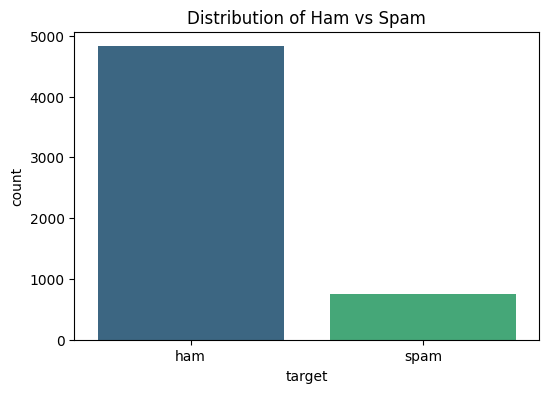

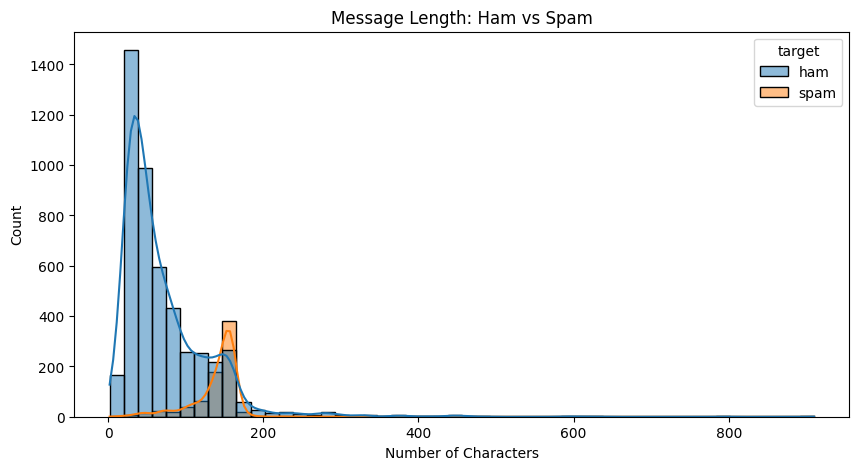

Insights: Spam messages tend to be significantly longer than Ham messages.


In [34]:
# EDA & Visualization
# Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='target', palette='viridis')
plt.title('Distribution of Ham vs Spam')
plt.show()

# Feature Engineering: Message Length
df['message_len'] = df['text'].apply(len)

# Visualizing Length Difference
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='message_len', hue='target', bins=50, kde=True)
plt.title('Message Length: Ham vs Spam')
plt.xlabel('Number of Characters')
plt.show()

print("Insights: Spam messages tend to be significantly longer than Ham messages.")

**4. Code Structure**

Lets now create 3 reusable functions for preprocessing, prediction and visualization.

In [35]:
# Defining the Cleaning Function
def text_preprocess(message):
    # Remove punctuation
    nopunc = [char for char in message if char not in string.punctuation]
    nopunc = ''.join(nopunc)

    # Remove stopwords and return clean list
    return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]

print("Preprocessing function defined for modular use.")

Preprocessing function defined for modular use.


**5. Structured Design / OOP**



In [36]:
# OOP Design for the Spam Detector
class edtechSpamDetector:
    def __init__(self, vectorizer, model):
        self.vectorizer = vectorizer
        self.model = model

    def predict_message(self, text):
        vectorized_text = self.vectorizer.transform([text])
        prediction = self.model.predict(vectorized_text)
        return "Spam" if prediction[0] == 'spam' else "Ham"

print("edtechSpamDetector Class structure created.")

edtechSpamDetector Class structure created.


**6. Preprocessing**

NLP: cleaning, tokenization, TF-IDF.

In [37]:
# Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF with our custom analyzer
tfidf = TfidfVectorizer(analyzer=text_preprocess)

# Transform the text data into a numerical feature matrix (X)
X = tfidf.fit_transform(df['text'])
y = df['target']

print(f"Feature extraction complete. Matrix shape: {X.shape}")

Feature extraction complete. Matrix shape: (5572, 11304)


**7. Model Development**

We now train and test

In [38]:
# Model Training
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# Split data Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = MultinomialNB()
model.fit(X_train, y_train)

print("Naive Bayes Model trained successfully.")

Naive Bayes Model trained successfully.


**9. Evaluation Error Analysis**

In [39]:
# Evaluation and Error Analysis
from sklearn.metrics import classification_report, confusion_matrix

predictions = model.predict(X_test)

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, predictions))

print("\n--- Classification Report ---")
print(classification_report(y_test, predictions))

--- Confusion Matrix ---
[[965   0]
 [ 39 111]]

--- Classification Report ---
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.74      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



**10.Streamlit App**


Your Final GitHub Checklist for Project 3:
To get full marks, ensure these files are in your repository:

Project3_Spam_Detection.ipynb (Your full notebook with all 11 steps).

app.py (The code above).

spam_model.pkl (Downloaded from Colab).

tfidf_vectorizer.pkl (Downloaded from Colab).

requirements.txt (Make sure it includes nltk, scikit-learn, streamlit, and joblib).